# Steps:

Step 1: Import Libraries

Step 2: Load Dataset

Step 3: Data Understanding

Step 4: Data Visualization

Step 5: Machine Learning Part

# Data Analysis Report

# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Step 2: Load Dataset

In [2]:
# 1. Set the path to your Excel file
# Use r'' to avoid path errors on Windows
file_path = r'HBL match data.pk.xlsx' 

# Check if file exists to avoid FileNotFoundError
if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found in the current folder.")
    print("Please ensure the file is in:", os.getcwd())
else:
    # 2. Load the Excel file
    # This reads the specific sheets by name or index
    try:
        # Load Batting Data (Sheet 1)
        # We use skiprows if there's junk at the top, or clean it after loading
        sheet1 = pd.read_excel(file_path, sheet_name=0)
        
        # Cleaning Sheet 1: Removing the 4 empty columns at the start
        batting_df = sheet1.iloc[:, 4:].copy()
        batting_df.columns = batting_df.iloc[0] # Set the player info row as header
        batting_df = batting_df[1:].reset_index(drop=True)
        
        # Convert numeric columns
        cols_to_fix = ['Runs', 'Balls', '4s', '6s', 'SR']
        for col in cols_to_fix:
            batting_df[col] = pd.to_numeric(batting_df[col], errors='coerce')

        # Load Bowling Data (Sheet 2)
        bowling_df = pd.read_excel(file_path, sheet_name=1)

        # 3. Print Results
        print("--- Batting Data Cleaned ---")
        print(batting_df.head())
        
        print("\n--- Bowling Data ---")
        print(bowling_df.head())

        # Optional: Save cleaned data to a new Excel file
        with pd.ExcelWriter('Cleaned_Match_Data.xlsx') as writer:
            batting_df.to_excel(writer, sheet_name='Batting', index=False)
            bowling_df.to_excel(writer, sheet_name='Bowling', index=False)
        print("\nSuccess! Cleaned data saved to 'Cleaned_Match_Data.xlsx'")

    except Exception as e:
        print(f"An error occurred: {e}")

--- Batting Data Cleaned ---
0         Player               Team  Runs  Balls  4s  6s      SR  Status
0     Babar Azam      Karachi Kings    78     56   7   2  139.28  Caught
1  Sharjeel Khan      Karachi Kings    19     15   3   0  126.66     LBW
2      Jason Roy  Quetta Gladiators    54     28   6   4  192.85  Bowled
3    James Vince  Quetta Gladiators    18     15   2   0  120.00  Caught

--- Bowling Data ---
             Player               Team  Overs  Maidens  Runs  Wickets  Econ
0     Mohammad Amir      Karachi Kings      4        0    25        2  6.25
1        Imad Wasim      Karachi Kings      4        0    31        3  7.75
2  Mohammad Hasnain  Quetta Gladiators      4        0    38        2  9.50

Success! Cleaned data saved to 'Cleaned_Match_Data.xlsx'


# Step 3:  Data Understanding

In [11]:
print(batting_df.head())
print(batting_df.info())
print(batting_df.describe())
print(bowling_df.head())
print(bowling_df.info())
print(bowling_df.describe())

0         Player               Team  Runs  Balls  4s  6s      SR  Status  \
0     Babar Azam      Karachi Kings    78     56   7   2  139.28  Caught   
1  Sharjeel Khan      Karachi Kings    19     15   3   0  126.66     LBW   
2      Jason Roy  Quetta Gladiators    54     28   6   4  192.85  Bowled   
3    James Vince  Quetta Gladiators    18     15   2   0  120.00  Caught   

0  Team_Encoded  Status_Encoded  
0             0               1  
1             0               2  
2             1               0  
3             1               1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Player          4 non-null      object 
 1   Team            4 non-null      object 
 2   Runs            4 non-null      int64  
 3   Balls           4 non-null      int64  
 4   4s              4 non-null      int64  
 5   6s              4 non-null  

# Step 4: Data Visualization

# 4.1 Individual Batting Performance:

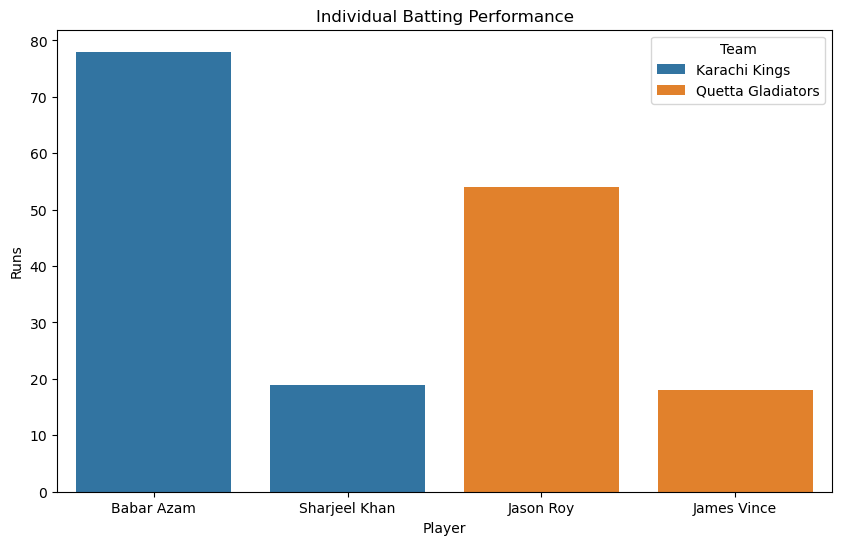

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing Individual Player Scores
plt.figure(figsize=(10, 6))
sns.barplot(x='Player', y='Runs', hue='Team', data=batting_df)
plt.title('Individual Batting Performance')
plt.ylabel('Runs')
plt.savefig('player_performance.png')

# 4.2 Individual Bowling Performance:Wickets Taken:

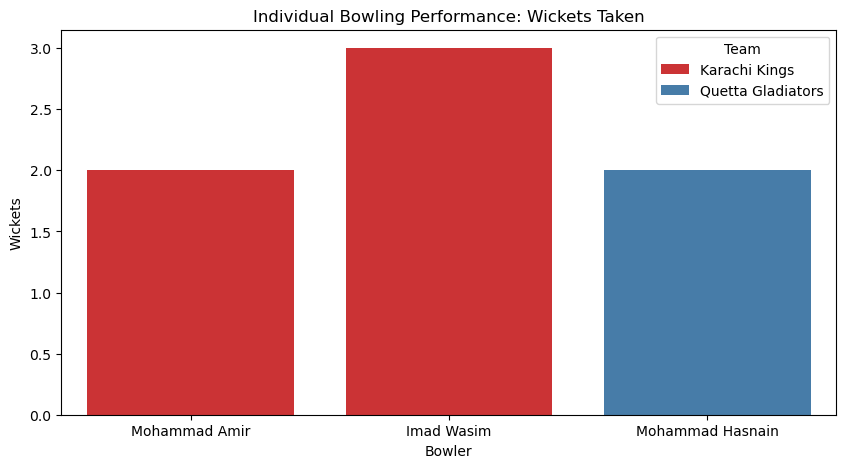

In [12]:
# Ensure numeric types for analysis
bowling_df['Wickets'] = pd.to_numeric(bowling_df['Wickets'])
bowling_df['Econ'] = pd.to_numeric(bowling_df['Econ'])

# --- Visualization 1: Wickets Taken by Each Player ---
plt.figure(figsize=(10, 5))
sns.barplot(x='Player', y='Wickets', hue='Team', data=bowling_df, palette='Set1')
plt.title('Individual Bowling Performance: Wickets Taken')
plt.ylabel('Wickets')
plt.xlabel('Bowler')
plt.savefig('bowling_wickets.png')
plt.show()

# 4.3 Individual Batting Performance:Economy Rate:

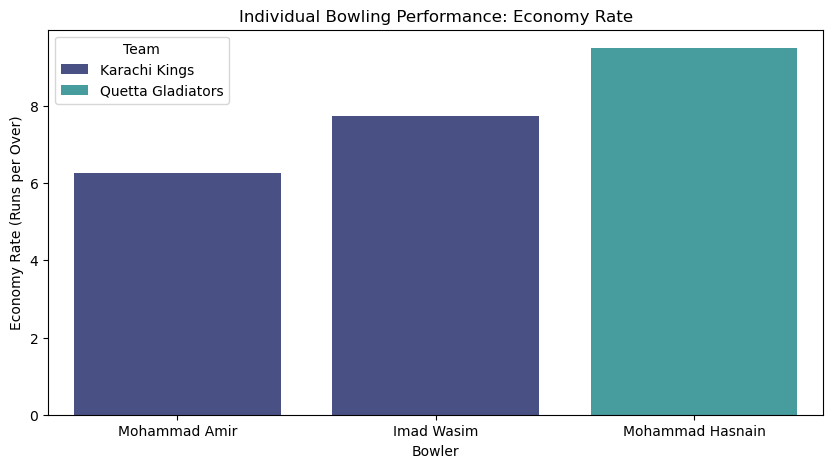

In [6]:
# --- Visualization 2: Economy Rate (Lower is Better) ---
plt.figure(figsize=(10, 5))
# Sort by Economy to see the most economical bowlers first
bowling_df_sorted = bowling_df.sort_values('Econ')
sns.barplot(x='Player', y='Econ', hue='Team', data=bowling_df_sorted, palette='mako')
plt.title('Individual Bowling Performance: Economy Rate')
plt.ylabel('Economy Rate (Runs per Over)')
plt.xlabel('Bowler')
plt.savefig('bowling_economy.png')
plt.show()

# 4.4 Batting Strike Rate Comparison (Runs Per 100 Balls):

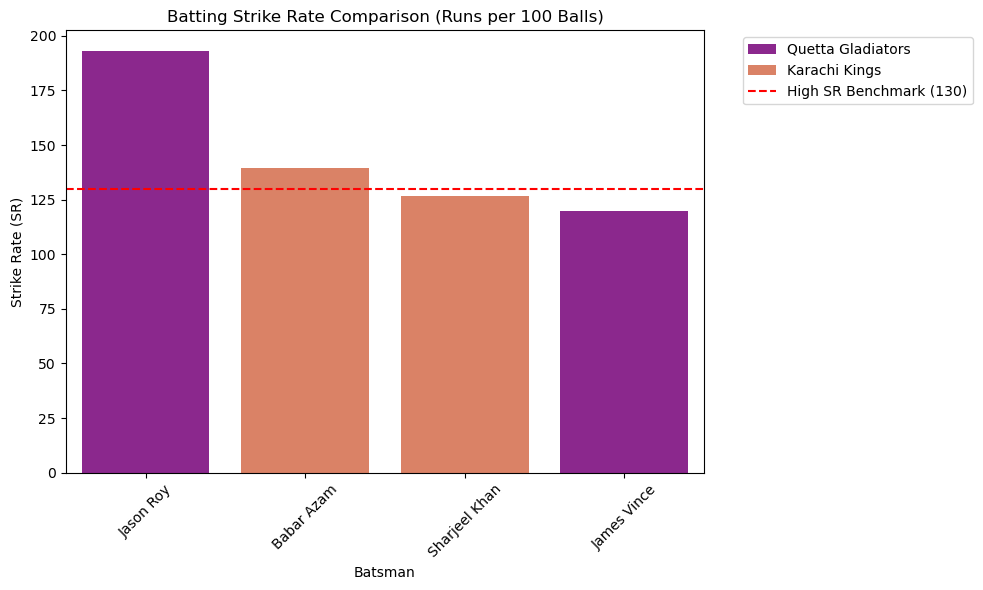

In [7]:
# 2. Visualize Batting Strike Rate
plt.figure(figsize=(10, 6))

# Sorting by SR helps to see the most aggressive batsmen at the top
batting_df_sorted = batting_df.sort_values('SR', ascending=False)

sns.barplot(x='Player', y='SR', hue='Team', data=batting_df_sorted, palette='plasma')

# Adding a horizontal line for a "Good Strike Rate" benchmark (e.g., 130)
plt.axhline(y=130, color='red', linestyle='--', label='High SR Benchmark (130)')

plt.title('Batting Strike Rate Comparison (Runs per 100 Balls)')
plt.ylabel('Strike Rate (SR)')
plt.xlabel('Batsman')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 3. Save the visualization
plt.savefig('batting_strike_rate.png')
plt.show()


# 4.5 Overall Performance of both teams:

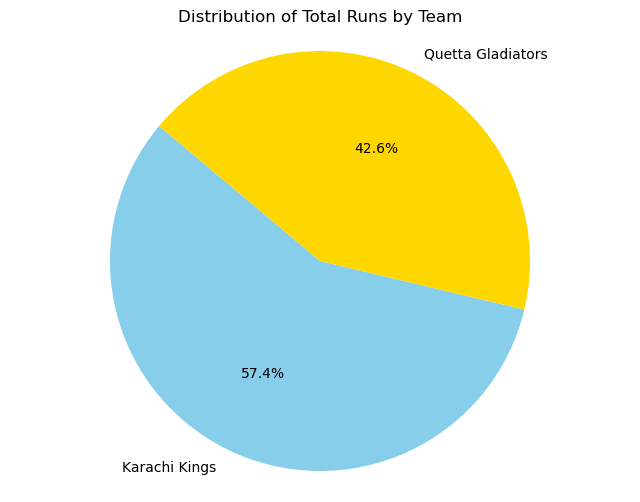

In [9]:
import matplotlib.pyplot as plt

# Data for the pie chart (Example: Total Runs by Team)
team_runs = batting_df.groupby('Team')['Runs'].sum()

plt.figure(figsize=(8, 6))
plt.pie(team_runs, labels=team_runs.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'gold'])
plt.title('Distribution of Total Runs by Team')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Step 5: Machine Learning Part

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# --- Step 1: Preprocessing ---
# Handle categorical data (Team and Status) using Label Encoding
le = LabelEncoder()
batting_df['Team_Encoded'] = le.fit_transform(batting_df['Team'])
batting_df['Status_Encoded'] = le.fit_transform(batting_df['Status'])

# --- Step 2: Define Features (X) and Target (y) ---
# We use Balls, 4s, 6s, and SR to predict Runs
X = batting_df[['Balls', '4s', '6s', 'SR', 'Team_Encoded']]
y = batting_df['Runs']

# --- Step 3: Split the Dataset ---
# We split it into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 3 rows
Testing set size: 1 rows


# 5.1 Actual vs Predicted:

In [25]:
from sklearn.linear_model import LinearRegression
# 1. Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 2. Generate Predictions on the test set
y_pred = model.predict(X_test)

# 3. Create the Actual vs Predicted Comparison DataFrame
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# Reset index to see them side-by-side clearly
comparison_df = comparison_df.reset_index(drop=True)
print(comparison_df.head())

   Actual  Predicted
0      19  19.826363


# 5.2 Actual vs Predicted Scatter Plot Graph:

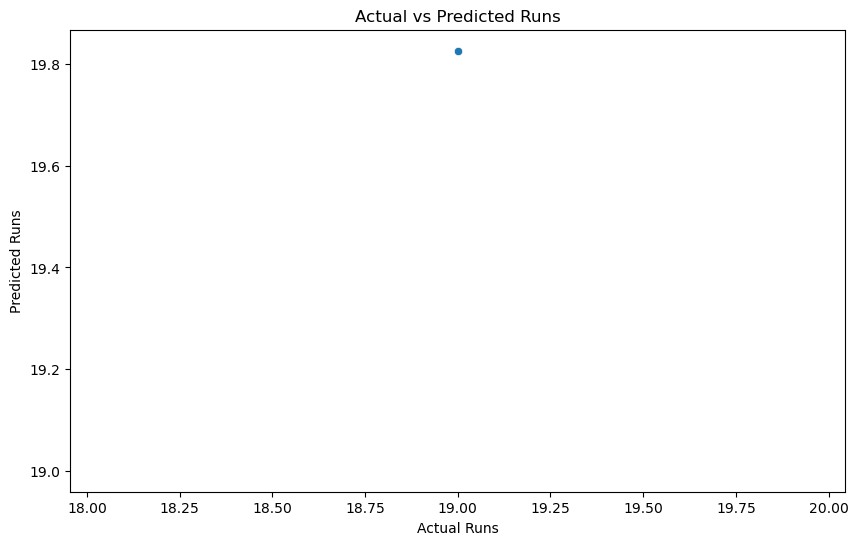

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Diagonal line
plt.xlabel('Actual Runs')
plt.ylabel('Predicted Runs')
plt.title('Actual vs Predicted Runs')
plt.show()

# 5.3 Actual vs Predicted Bar Graph:

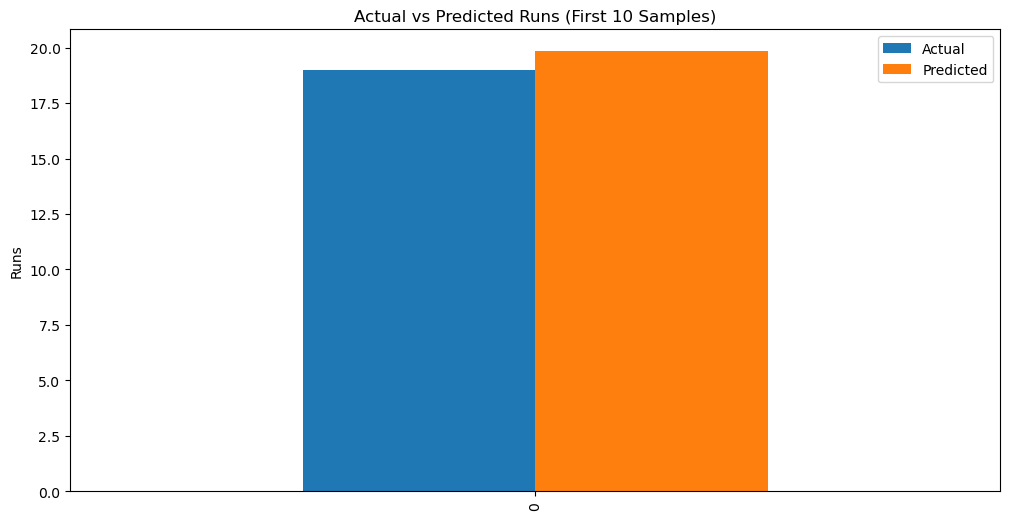

In [18]:
# Taking the first 10 samples for better visibility
comparison_df.head(10).plot(kind='bar', figsize=(12, 6))
plt.title('Actual vs Predicted Runs (First 10 Samples)')
plt.ylabel('Runs')
plt.show()

# 5.4 MAE,MSE,RMSE and R2:

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# 2. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# 3. Root Mean Squared Error (RMSE)
# We take the square root of MSE
rmse = np.sqrt(mse)

# 4. R-squared Score
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (R2): {r2:.2f}")

Mean Absolute Error (MAE): 0.83
Mean Squared Error (MSE): 0.68
Root Mean Squared Error (RMSE): 0.83
R-squared Score (R2): nan


C:\Users\Aiza Iqbal\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
